Models loading...


Loading weights:   0%|          | 0/473 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.cls.predictions.bias to text_decoder.cls.predictions.decoder.bias, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForConditionalGeneration LOAD REPORT from: Salesforce/blip-image-captioning-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identic

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Models loaded.

MULTI-AGENT FAULT TOLERANCE EXPERIMENT
Downloaded: 1/30
Downloaded: 2/30
Downloaded: 3/30
Downloaded: 4/30
Downloaded: 5/30
Downloaded: 6/30
Downloaded: 7/30
Downloaded: 8/30
Downloaded: 9/30
Downloaded: 10/30
Downloaded: 11/30
Downloaded: 12/30
Downloaded: 13/30
Downloaded: 14/30
Downloaded: 15/30
Downloaded: 16/30
Downloaded: 17/30
Downloaded: 18/30
Downloaded: 19/30
Downloaded: 20/30
Downloaded: 21/30
Downloaded: 22/30
Downloaded: 23/30
Downloaded: 24/30
Downloaded: 25/30
Downloaded: 26/30
Downloaded: 27/30
Downloaded: 28/30
Downloaded: 29/30
Downloaded: 30/30
Successfully downloaded 30 images

Running experiment...
Progress: 5/30
Progress: 10/30
Progress: 15/30
Progress: 20/30
Progress: 25/30
Progress: 30/30
Experiment complete.

EXPERIMENT RESULTS

Total images: 30
Disagreements (potential faults): 18
Agreements: 12

Disagreement rate: 60.00%
Agreement rate: 40.00%

Similarity statistics:
   Mean similarity: 0.613
   Median similarity: 0.600
   Std deviation: 0.259

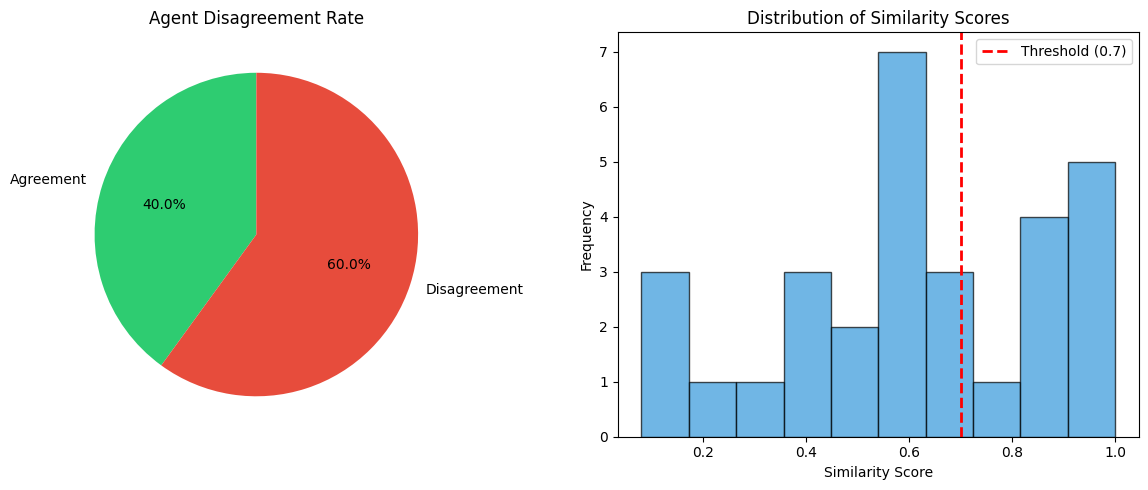


Plot saved as results.png
Results exported to results.csv

SAMPLE RESULTS (First 5 images)

Image: img_1.jpg
   Generator: two cats sleeping on a couch
   Verifier: two cats sleeping on a couch with a remote
   Similarity: 0.917
   Fault detected: False

Image: img_2.jpg
   Generator: a kitchen with a table and chairs in it
   Verifier: the kitchen has all white appliances and a table
   Similarity: 0.679
   Fault detected: True

Image: img_3.jpg
   Generator: a woman walking down the street
   Verifier: a woman walking on the sidewalk
   Similarity: 0.704
   Fault detected: False

Image: img_4.jpg
   Generator: a woman in a kitchen
   Verifier: a woman standing in a kitchen
   Similarity: 0.903
   Fault detected: False

Image: img_5.jpg
   Generator: a skate park
   Verifier: a gray and white sky
   Similarity: 0.138
   Fault detected: True


In [ ]:
!pip install transformers torch pillow matplotlib requests sentence-transformers -q

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
import torch
import requests
from io import BytesIO
import warnings
warnings.filterwarnings('ignore')

from transformers import BlipProcessor, BlipForConditionalGeneration
from sentence_transformers import SentenceTransformer, util

print("Models loading...")

blip_processor = BlipProcessor.from_pretrained("Salesforce/blip-image-captioning-base")
blip_model = BlipForConditionalGeneration.from_pretrained("Salesforce/blip-image-captioning-base")

similarity_model = SentenceTransformer('all-MiniLM-L6-v2')

print("Models loaded.")

class Generator:
    def __init__(self, processor, model):
        self.processor = processor
        self.model = model

    def generate(self, image):
        inputs = self.processor(image, return_tensors="pt")
        out = self.model.generate(**inputs, max_length=30)
        caption = self.processor.decode(out[0], skip_special_tokens=True)
        return caption

class Verifier:
    def __init__(self, processor, model):
        self.processor = processor
        self.model = model

    def generate(self, image):
        inputs = self.processor(image, return_tensors="pt")
        out = self.model.generate(**inputs, max_length=30, do_sample=True, temperature=0.8, top_p=0.9)
        caption = self.processor.decode(out[0], skip_special_tokens=True)
        return caption

class Critic:
    def __init__(self, model):
        self.model = model

    def compute_similarity(self, text1, text2):
        embedding1 = self.model.encode(text1, convert_to_tensor=True)
        embedding2 = self.model.encode(text2, convert_to_tensor=True)
        sim = util.pytorch_cos_sim(embedding1, embedding2)
        return sim.item()

    def detect_fault(self, gen_output, ver_output, threshold=0.7):
        sim = self.compute_similarity(gen_output, ver_output)
        is_fault = sim < threshold
        return is_fault, sim

def download_sample_images(num_images=30):
    urls_working = [
        "http://images.cocodataset.org/val2017/000000039769.jpg",
        "http://images.cocodataset.org/val2017/000000037777.jpg",
        "http://images.cocodataset.org/val2017/000000252219.jpg",
        "http://images.cocodataset.org/val2017/000000397133.jpg",
        "http://images.cocodataset.org/val2017/000000087038.jpg"
    ]

    images = []
    image_names = []

    print(f"Downloading up to {num_images} images...")

    for i in range(num_images):
        url = urls_working[i % len(urls_working)]
        try:
            response = requests.get(url, timeout=10)
            if response.status_code == 200:
                img = Image.open(BytesIO(response.content)).convert('RGB')
                images.append(img)
                image_names.append(f"img_{i+1}.jpg")
                print(f"Downloaded: {len(images)}/{num_images}")
            else:
                print(f"Failed attempt {i+1}")
        except Exception as e:
            print(f"Failed attempt {i+1}")
            continue

    print(f"Successfully downloaded {len(images)} images")
    return images, image_names

def run_experiment(images, image_names, similarity_threshold=0.7):
    generator = Generator(blip_processor, blip_model)
    verifier = Verifier(blip_processor, blip_model)
    critic = Critic(similarity_model)

    results = []

    print("\nRunning experiment...")

    for i, (img, name) in enumerate(zip(images, image_names)):
        try:
            gen_out = generator.generate(img)
            ver_out = verifier.generate(img)
            is_fault, similarity = critic.detect_fault(gen_out, ver_out, threshold=similarity_threshold)

            results.append({
                'image_name': name,
                'generator': gen_out,
                'verifier': ver_out,
                'similarity': similarity,
                'is_fault': is_fault
            })

            if (i + 1) % 5 == 0:
                print(f"Progress: {i+1}/{len(images)}")
        except Exception as e:
            print(f"Error on image {i+1}: {e}")
            continue

    print("Experiment complete.")
    return results

def compute_statistics(results):
    total = len(results)
    if total == 0:
        return {
            'total_images': 0,
            'fault_count': 0,
            'disagreement_rate': 0,
            'agreement_rate': 0,
            'avg_similarity': 0,
            'median_similarity': 0,
            'std_similarity': 0,
            'min_similarity': 0,
            'max_similarity': 0,
            'similarities': []
        }

    fault_count = sum(1 for r in results if r['is_fault'])
    similarities = [r['similarity'] for r in results]

    stats = {
        'total_images': total,
        'fault_count': fault_count,
        'disagreement_rate': fault_count / total,
        'agreement_rate': 1 - (fault_count / total),
        'avg_similarity': np.mean(similarities),
        'median_similarity': np.median(similarities),
        'std_similarity': np.std(similarities),
        'min_similarity': min(similarities),
        'max_similarity': max(similarities),
        'similarities': similarities
    }

    return stats

def print_results(stats):
    print("\n" + "="*50)
    print("EXPERIMENT RESULTS")
    print("="*50)

    print(f"\nTotal images: {stats['total_images']}")
    print(f"Disagreements (potential faults): {stats['fault_count']}")
    print(f"Agreements: {stats['total_images'] - stats['fault_count']}")

    print(f"\nDisagreement rate: {stats['disagreement_rate']:.2%}")
    print(f"Agreement rate: {stats['agreement_rate']:.2%}")

    print(f"\nSimilarity statistics:")
    print(f"   Mean similarity: {stats['avg_similarity']:.3f}")
    print(f"   Median similarity: {stats['median_similarity']:.3f}")
    print(f"   Std deviation: {stats['std_similarity']:.3f}")
    print(f"   Min similarity: {stats['min_similarity']:.3f}")
    print(f"   Max similarity: {stats['max_similarity']:.3f}")

def plot_results(stats):
    if stats['total_images'] == 0:
        print("No results to plot")
        return

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    labels = ['Agreement', 'Disagreement']
    sizes = [stats['agreement_rate']*100, stats['disagreement_rate']*100]
    colors = ['#2ecc71', '#e74c3c']
    axes[0].pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90)
    axes[0].set_title('Agent Disagreement Rate')

    axes[1].hist(stats['similarities'], bins=10, color='#3498db', edgecolor='black', alpha=0.7)
    axes[1].axvline(x=0.7, color='red', linestyle='--', linewidth=2, label='Threshold (0.7)')
    axes[1].set_xlabel('Similarity Score')
    axes[1].set_ylabel('Frequency')
    axes[1].set_title('Distribution of Similarity Scores')
    axes[1].legend()

    plt.tight_layout()
    plt.savefig('results.png', dpi=150)
    plt.show()
    print("\nPlot saved as results.png")

def export_to_csv(results, filename='results.csv'):
    import csv
    with open(filename, 'w', newline='', encoding='utf-8') as f:
        writer = csv.writer(f)
        writer.writerow(['Image', 'Generator Output', 'Verifier Output', 'Similarity', 'Is Fault'])
        for r in results:
            writer.writerow([r['image_name'], r['generator'], r['verifier'],
                           f"{r['similarity']:.3f}", r['is_fault']])
    print(f"Results exported to {filename}")

print("\n" + "="*50)
print("MULTI-AGENT FAULT TOLERANCE EXPERIMENT")
print("="*50)

images, image_names = download_sample_images(num_images=30)

if len(images) == 0:
    print("No images downloaded. Check internet connection.")
else:
    results = run_experiment(images, image_names, similarity_threshold=0.7)
    stats = compute_statistics(results)
    print_results(stats)
    plot_results(stats)
    export_to_csv(results)

    print("\n" + "="*50)
    print("SAMPLE RESULTS (First 5 images)")
    print("="*50)
    for i in range(min(5, len(results))):
        r = results[i]
        print(f"\nImage: {r['image_name']}")
        print(f"   Generator: {r['generator']}")
        print(f"   Verifier: {r['verifier']}")
        print(f"   Similarity: {r['similarity']:.3f}")
        print(f"   Fault detected: {r['is_fault']}")

# New Section